# Question 1: TF-IDF Vectorization
# Task: Convert the text data into a TF-IDF matrix and display the features.

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "I love machine learning and NLP.",
    "TF-IDF is a popular method in text mining.",
    "Natural Language Processing is fascinating.",
    "I love learning new things in NLP."
]

tfidf_vect = TfidfVectorizer()
tfidf_matrix = tfidf_vect.fit_transform(documents)
feature_names = tfidf_vect.get_feature_names_out()
print("TF-IDF Matrix:\n", tfidf_matrix.toarray().round(2))
print("\nFeature Names:\n", feature_names)


TF-IDF Matrix:
 [[0.51 0.   0.   0.   0.   0.   0.4  0.4  0.51 0.   0.   0.   0.   0.4
  0.   0.   0.   0.   0.  ]
 [0.   0.   0.37 0.29 0.29 0.   0.   0.   0.   0.37 0.37 0.   0.   0.
  0.37 0.   0.37 0.37 0.  ]
 [0.   0.47 0.   0.   0.37 0.47 0.   0.   0.   0.   0.   0.47 0.   0.
  0.   0.47 0.   0.   0.  ]
 [0.   0.   0.   0.37 0.   0.   0.37 0.37 0.   0.   0.   0.   0.47 0.37
  0.   0.   0.   0.   0.47]]

Feature Names:
 ['and' 'fascinating' 'idf' 'in' 'is' 'language' 'learning' 'love'
 'machine' 'method' 'mining' 'natural' 'new' 'nlp' 'popular' 'processing'
 'text' 'tf' 'things']


# Question 2: CountVectorizer
# Task: Use CountVectorizer to find word frequency.

In [1]:
from sklearn.feature_extraction.text import CountVectorizer

texts = [
    "ChatGPT is an LLM model.",
    "ChatGPT is useful for NLP tasks.",
    "NLP involves working with language."
]

count_vect = CountVectorizer()
count_matrix = count_vect.fit_transform(texts)
feature_names = count_vect.get_feature_names_out()
print("Count Matrix:\n", count_matrix.toarray())
print("\nFeature Names:\n", feature_names)


Count Matrix:
 [[1 1 0 0 1 0 1 1 0 0 0 0 0]
 [0 1 1 0 1 0 0 0 1 1 1 0 0]
 [0 0 0 1 0 1 0 0 1 0 0 1 1]]

Feature Names:
 ['an' 'chatgpt' 'for' 'involves' 'is' 'language' 'llm' 'model' 'nlp'
 'tasks' 'useful' 'with' 'working']


# Question 3: Topic Modeling using LDA
# Task: Apply Latent Dirichlet Allocation (LDA) to find topics from the text.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

documents = [
    "Data science is an interdisciplinary field.",
    "Artificial intelligence and machine learning are part of data science.",
    "Natural language processing helps computers understand text.",
    "Deep learning is useful in image and text processing."
]

tfidf_vect = TfidfVectorizer()
tfidf_matrix = tfidf_vect.fit_transform(documents)
feature_names = tfidf_vect.get_feature_names_out()

lda_model = LatentDirichletAllocation(n_components=2, random_state=10)
lda_model.fit(tfidf_matrix)

for index, topic in enumerate(lda_model.components_):
    print(f'Topic #{index+1}')
    print([feature_names[i] for i in topic.argsort()[-5:]] )


Topic #1
['field', 'an', 'processing', 'text', 'is']
Topic #2
['of', 'are', 'artificial', 'intelligence', 'machine']


# Question 4: Sentiment Analysis using VADER
# Task: Analyze sentiment of given text reviews.

In [34]:
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

sentences = [
    "I love the new feature, it's amazing!",
    "This update is terrible and frustrating.",
    "The service was okay, not the best.",
    "I’m so happy with the experience!",
    "Very disappointed. Will not recommend."
]

sia = SentimentIntensityAnalyzer()

for sentence in sentences:
    score = sia.polarity_scores(sentence)
    comp_score = score['compound']
    tot_score = 'Positive' if comp_score>0.5 else 'Negative' if comp_score<0.5 else 'Neutral'
    print(f'{sentence} -> {tot_score} with Compound Score: {comp_score}')


I love the new feature, it's amazing! -> Positive with Compound Score: 0.8516
This update is terrible and frustrating. -> Negative with Compound Score: -0.7184
The service was okay, not the best. -> Negative with Compound Score: -0.3544
I’m so happy with the experience! -> Positive with Compound Score: 0.6468
Very disappointed. Will not recommend. -> Negative with Compound Score: -0.6708


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\sulos\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


# Question 5: Generate a Word Cloud
# Task: Generate a word cloud from the input text.

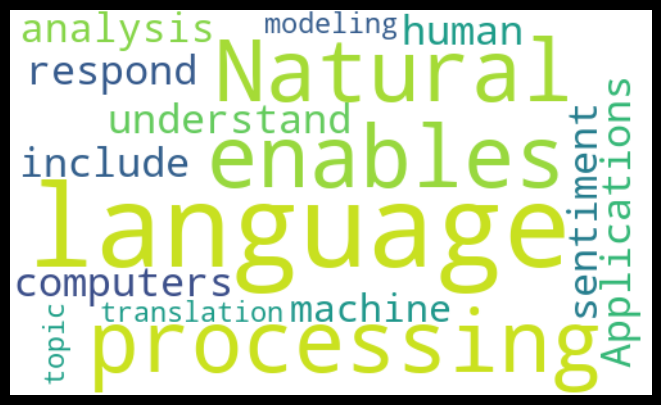

In [40]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = """
Natural language processing enables computers to understand and respond to human language.
Applications include sentiment analysis, machine translation, and topic modeling.
"""

wcloud = WordCloud(width=500, height=300, background_color='white').generate(text)
plt.figure(figsize=(10,5))
plt.imshow(wcloud, interpolation='bilinear')
plt.axis('off')
plt.show()
